# Project Overview: Multi-Label Classification with an Enzyme Substrate Dataset

**Objective:** Predict the specific enzyme commission classes (EC1 and EC2) and functional bio-activity of molecular structures based on chemical descriptors, molecular properties, and synthetic data dynamics.



## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s3e18')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s3e18


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import pickle
import json

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e18/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e18/test.csv')

In [4]:
train_df.head()

,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2,EC1,EC2,EC3,EC4,EC5,EC6
0,0,323.390782,9.879918,5.875576,5.875576,4.304757,4.304757,2.754513,1.749203,0.000000,...,4.794537,35.527357,0,0,1,1,0,0,0,0
1,1,273.723798,7.259037,4.441467,5.834958,3.285046,4.485235,2.201375,1.289775,45.135471,...,13.825658,44.707310,0,0,0,1,1,0,0,0
2,2,521.643822,10.911303,8.527859,11.050864,6.665291,9.519706,5.824822,1.770579,15.645394,...,17.964475,45.660120,0,0,1,1,0,0,1,0
3,3,567.431166,12.453343,7.089119,12.833709,6.478023,10.978151,7.914542,3.067181,95.639554,...,31.961948,87.509997,0,0,1,1,0,0,0,0
4,4,112.770735,4.414719,2.866236,2.866236,1.875634,1.875634,1.036450,0.727664,17.980451,...,9.589074,33.333333,2,2,1,0,1,1,1,0


In [5]:
test_df.head()

,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,PEOE_VSA14,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,SMR_VSA10,SMR_VSA5,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2
0,14838,344.632371,7.283603,4.473966,5.834958,3.412257,4.651530,2.096558,1.116433,49.458581,...,13.512441,0.000000,0.000000,0.000000,26.809272,24.539800,4.794537,47.304082,1,1
1,14839,1432.410201,10.663869,7.079026,8.065215,5.297097,5.297097,3.924155,2.569694,0.000000,...,0.000000,34.947374,98.323987,9.606882,0.000000,53.378235,0.000000,43.166667,0,0
2,14840,83.352608,3.931852,1.774215,1.774215,1.073446,1.073446,0.467830,0.170838,5.969305,...,5.969305,0.000000,0.000000,6.420822,11.752550,13.344559,9.589074,24.666667,1,1
3,14841,150.255712,5.912790,3.548812,3.548812,2.595128,2.595128,1.642813,0.694113,0.000000,...,59.935299,0.000000,0.000000,0.000000,17.744066,32.290168,4.794537,26.778866,0,0
4,14842,1817.276351,24.910940,15.540529,20.047314,12.535886,17.730988,11.979618,4.431173,84.554972,...,23.468091,25.609359,0.000000,37.099000,69.141353,38.704130,50.697492,102.583333,0,0


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 14838 non-null  int64  
 1   BertzCT            14838 non-null  float64
 2   Chi1               14838 non-null  float64
 3   Chi1n              14838 non-null  float64
 4   Chi1v              14838 non-null  float64
 5   Chi2n              14838 non-null  float64
 6   Chi2v              14838 non-null  float64
 7   Chi3v              14838 non-null  float64
 8   Chi4n              14838 non-null  float64
 9   EState_VSA1        14838 non-null  float64
 10  EState_VSA2        14838 non-null  float64
 11  ExactMolWt         14838 non-null  float64
 12  FpDensityMorgan1   14838 non-null  float64
 13  FpDensityMorgan2   14838 non-null  float64
 14  FpDensityMorgan3   14838 non-null  float64
 15  HallKierAlpha      14838 non-null  float64
 16  HeavyAtomMolWt     148

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9893 entries, 0 to 9892
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9893 non-null   int64  
 1   BertzCT            9893 non-null   float64
 2   Chi1               9893 non-null   float64
 3   Chi1n              9893 non-null   float64
 4   Chi1v              9893 non-null   float64
 5   Chi2n              9893 non-null   float64
 6   Chi2v              9893 non-null   float64
 7   Chi3v              9893 non-null   float64
 8   Chi4n              9893 non-null   float64
 9   EState_VSA1        9893 non-null   float64
 10  EState_VSA2        9893 non-null   float64
 11  ExactMolWt         9893 non-null   float64
 12  FpDensityMorgan1   9893 non-null   float64
 13  FpDensityMorgan2   9893 non-null   float64
 14  FpDensityMorgan3   9893 non-null   float64
 15  HallKierAlpha      9893 non-null   float64
 16  HeavyAtomMolWt     9893 

In [8]:
train_df.shape

(14838, 38)

In [9]:
test_df.shape

(9893, 32)

In [10]:
train_df.isnull().sum()

id                   0
BertzCT              0
Chi1                 0
Chi1n                0
Chi1v                0
Chi2n                0
Chi2v                0
Chi3v                0
Chi4n                0
EState_VSA1          0
EState_VSA2          0
ExactMolWt           0
FpDensityMorgan1     0
FpDensityMorgan2     0
FpDensityMorgan3     0
HallKierAlpha        0
HeavyAtomMolWt       0
Kappa3               0
MaxAbsEStateIndex    0
MinEStateIndex       0
NumHeteroatoms       0
PEOE_VSA10           0
PEOE_VSA14           0
PEOE_VSA6            0
PEOE_VSA7            0
PEOE_VSA8            0
SMR_VSA10            0
SMR_VSA5             0
SlogP_VSA3           0
VSA_EState9          0
fr_COO               0
fr_COO2              0
EC1                  0
EC2                  0
EC3                  0
EC4                  0
EC5                  0
EC6                  0
dtype: int64

In [11]:
test_df.isnull().sum()

id                   0
BertzCT              0
Chi1                 0
Chi1n                0
Chi1v                0
Chi2n                0
Chi2v                0
Chi3v                0
Chi4n                0
EState_VSA1          0
EState_VSA2          0
ExactMolWt           0
FpDensityMorgan1     0
FpDensityMorgan2     0
FpDensityMorgan3     0
HallKierAlpha        0
HeavyAtomMolWt       0
Kappa3               0
MaxAbsEStateIndex    0
MinEStateIndex       0
NumHeteroatoms       0
PEOE_VSA10           0
PEOE_VSA14           0
PEOE_VSA6            0
PEOE_VSA7            0
PEOE_VSA8            0
SMR_VSA10            0
SMR_VSA5             0
SlogP_VSA3           0
VSA_EState9          0
fr_COO               0
fr_COO2              0
dtype: int64

## 3. Exploratory Data Analysis

In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,14838.0,7418.500000,4283.505982,0.000000,3709.250000,7418.500000,11127.750000,14837.000000
BertzCT,14838.0,515.153604,542.456370,0.000000,149.103601,290.987941,652.652585,4069.959780
Chi1,14838.0,9.135189,6.819989,0.000000,4.680739,6.485270,11.170477,69.551167
Chi1n,14838.0,5.854307,4.647064,0.000000,2.844556,4.052701,7.486791,50.174588
Chi1v,14838.0,6.738497,5.866444,0.000000,2.932842,4.392859,8.527859,53.431954
Chi2n,14838.0,4.432570,3.760516,0.000000,1.949719,2.970427,5.788793,32.195368
Chi2v,14838.0,5.253221,4.925065,0.000000,2.034468,3.242775,6.609350,34.579313
Chi3v,14838.0,3.418749,3.436208,0.000000,1.160763,1.948613,4.502070,22.880836
Chi4n,14838.0,1.773472,1.865898,0.000000,0.503897,1.073261,2.534281,16.072810
EState_VSA1,14838.0,29.202823,31.728679,0.000000,5.969305,17.353601,44.876559,363.705954


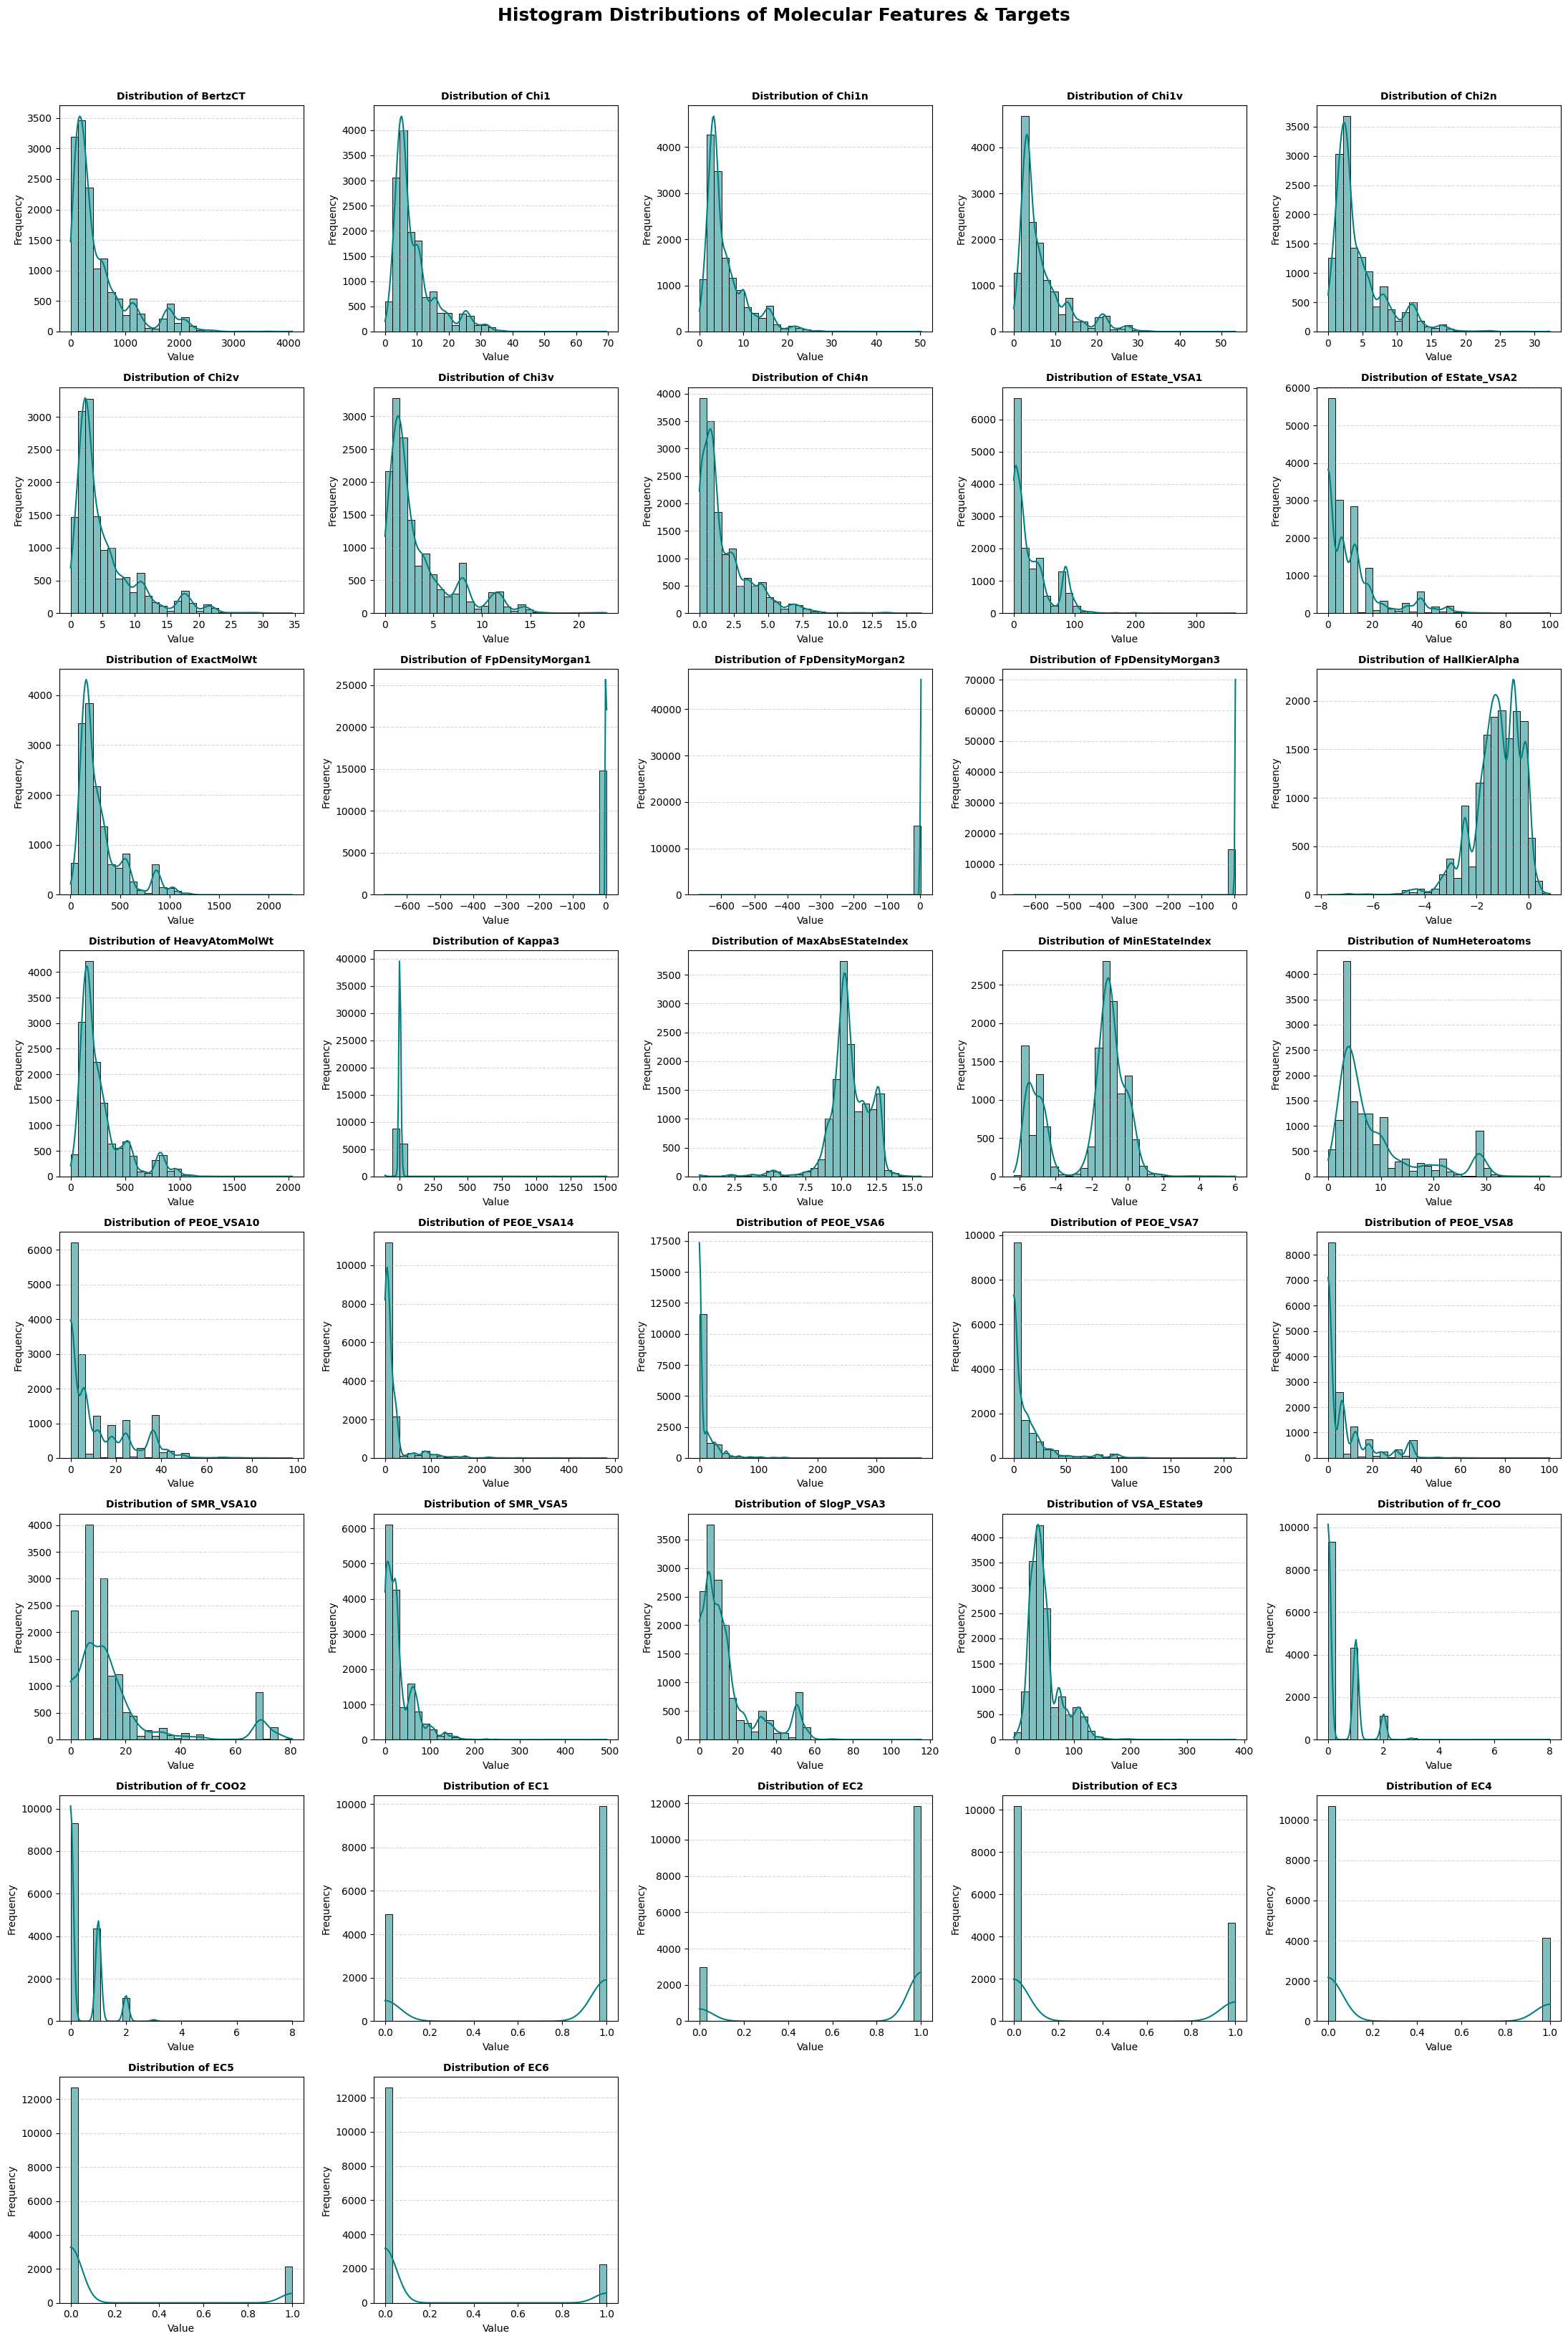

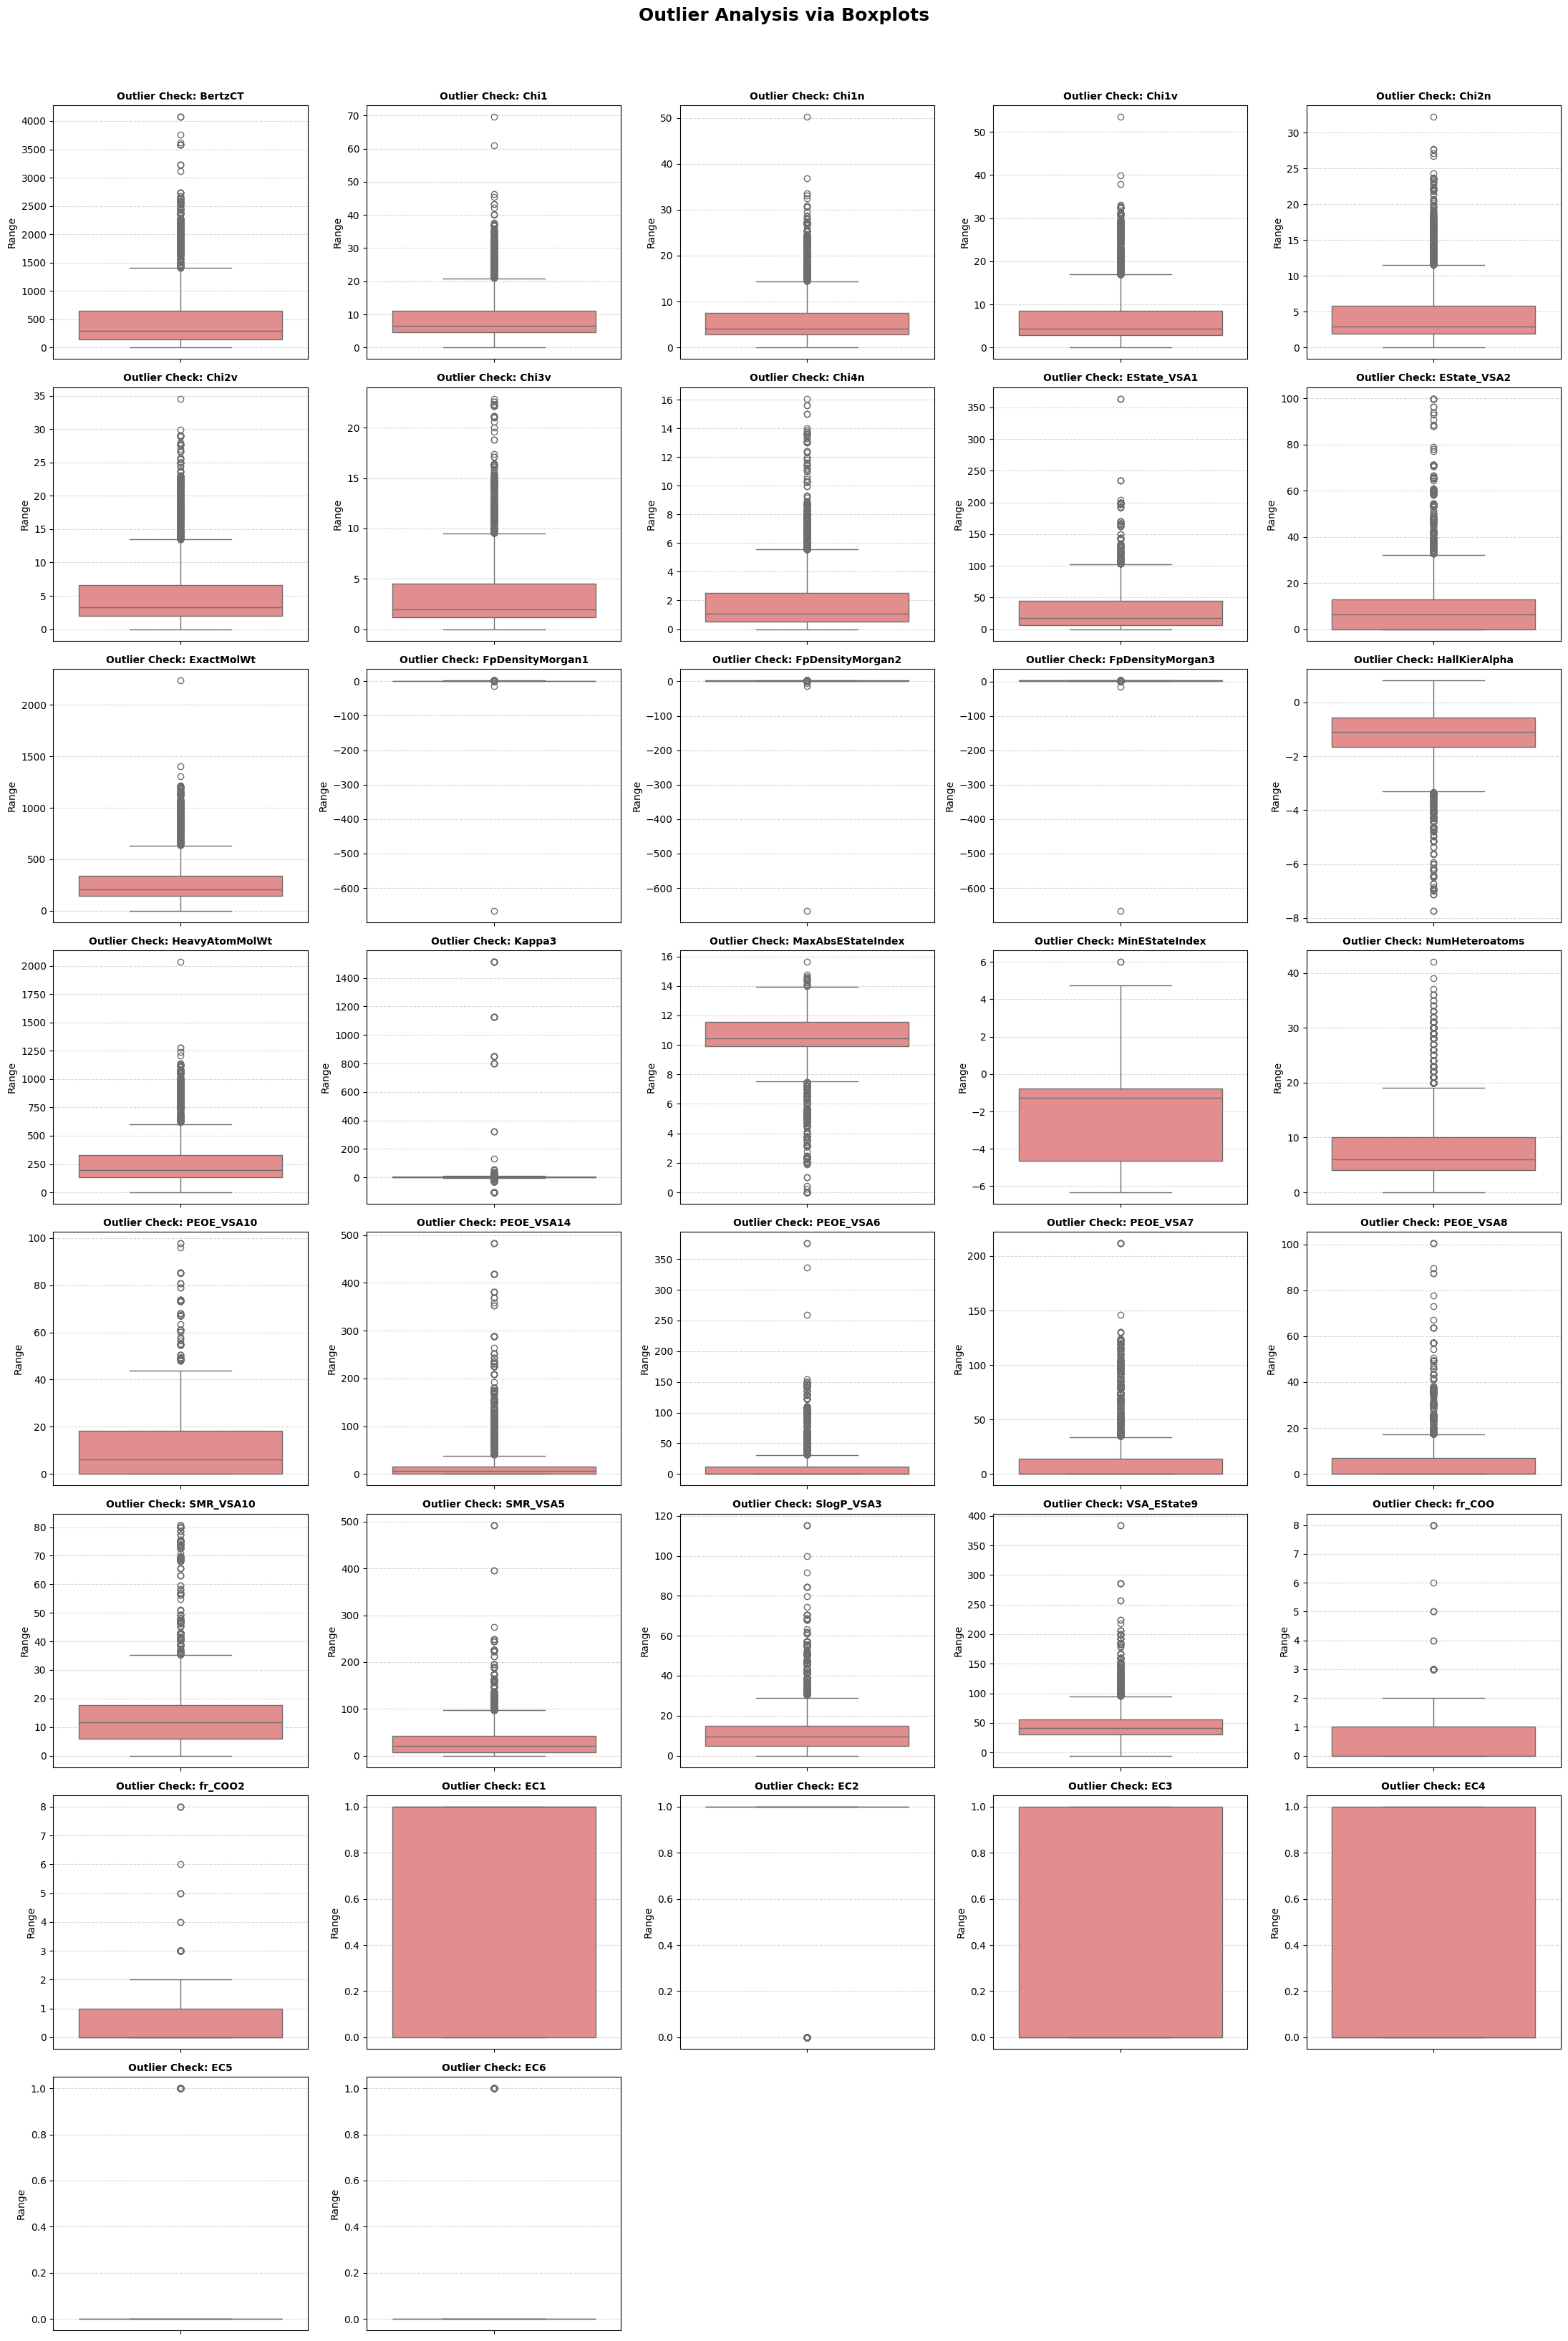

In [13]:
num_features = list(train_df.drop(columns=['id']).columns)
total_features = len(num_features)

columns_layout = 5
rows_layout = int(np.ceil(total_features / columns_layout))

# Histogram

fig, axes = plt.subplots(rows_layout, columns_layout, figsize=(22, rows_layout * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histogram Distributions of Molecular Features & Targets', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(rows_layout, columns_layout, figsize=(22, rows_layout * 4)) 
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Turning off unused empty axes if any remain
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

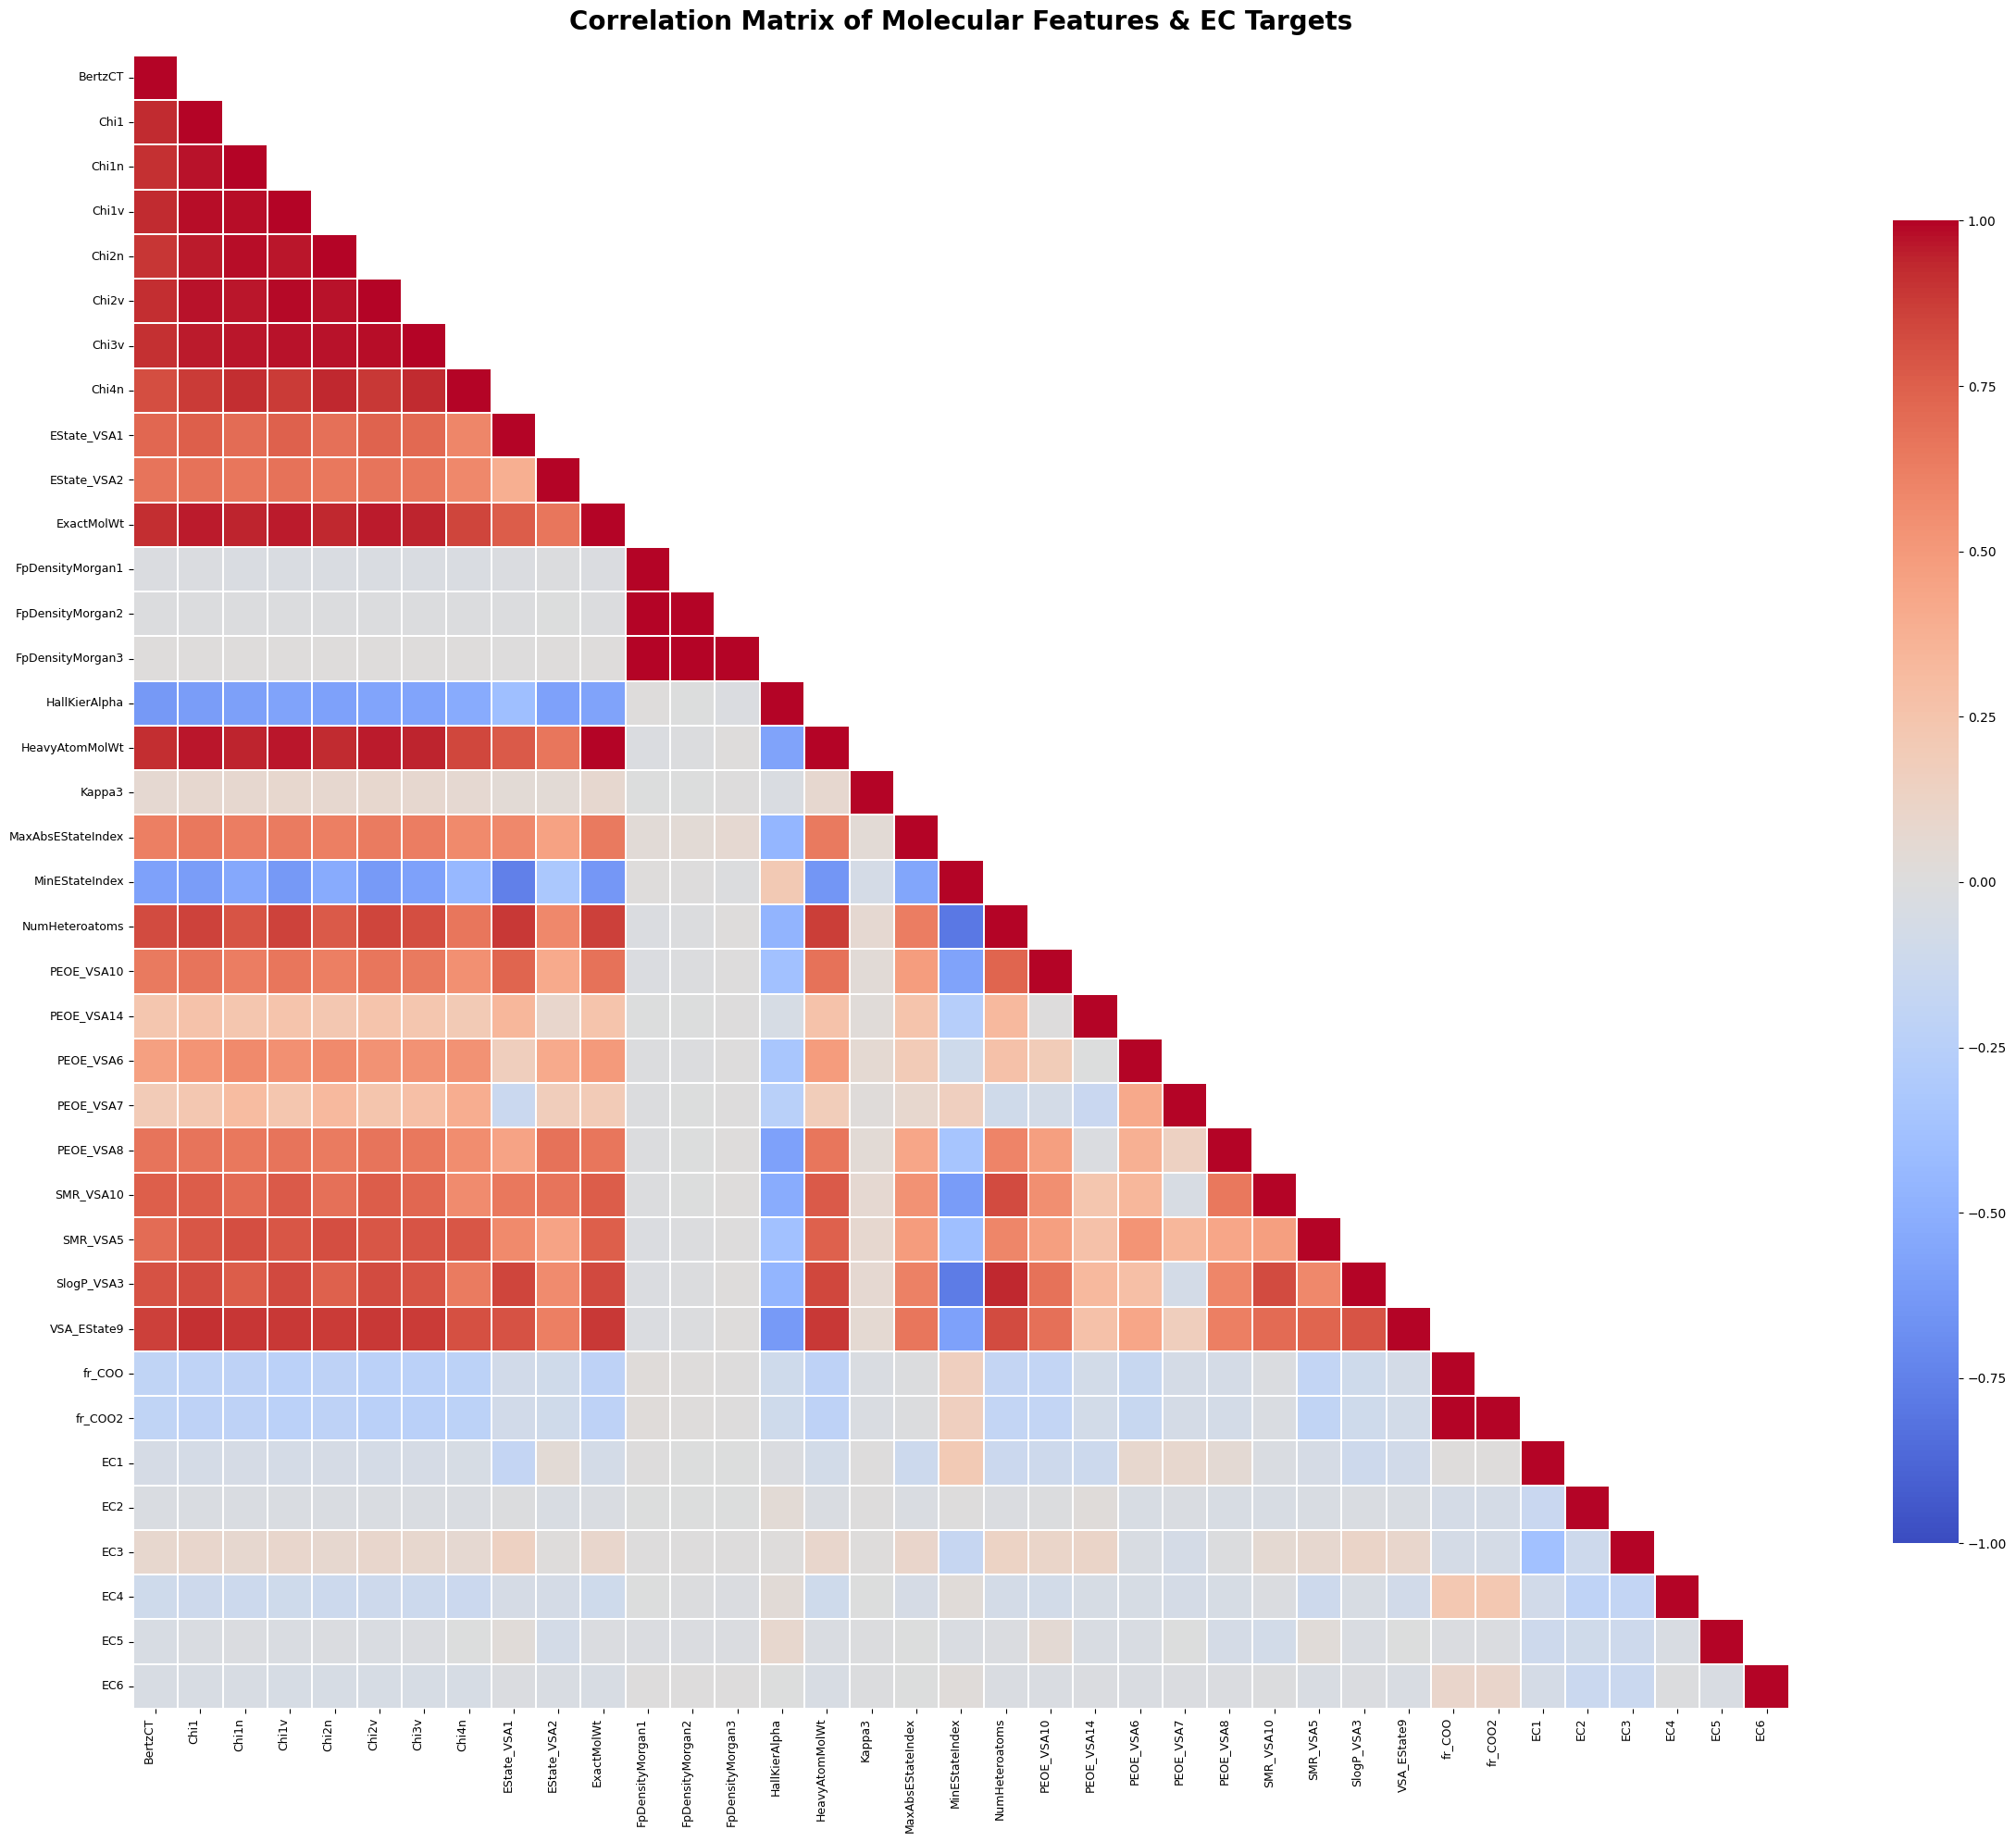

In [14]:
# Correlation
numerical_df = train_df.drop(columns=['id'])
corr_matrix = numerical_df.corr()

# Generating a mask for the upper triangle to remove redundant duplicate information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Larger figure size since we are plotting a 37x37 matrix
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=False, # Set to True if you want to read numbers, but 37x37 might be too tight for annotations
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8} 
)

plt.title('Correlation Matrix of Molecular Features & EC Targets', fontsize=20, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_57/4174128483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette="viridis")


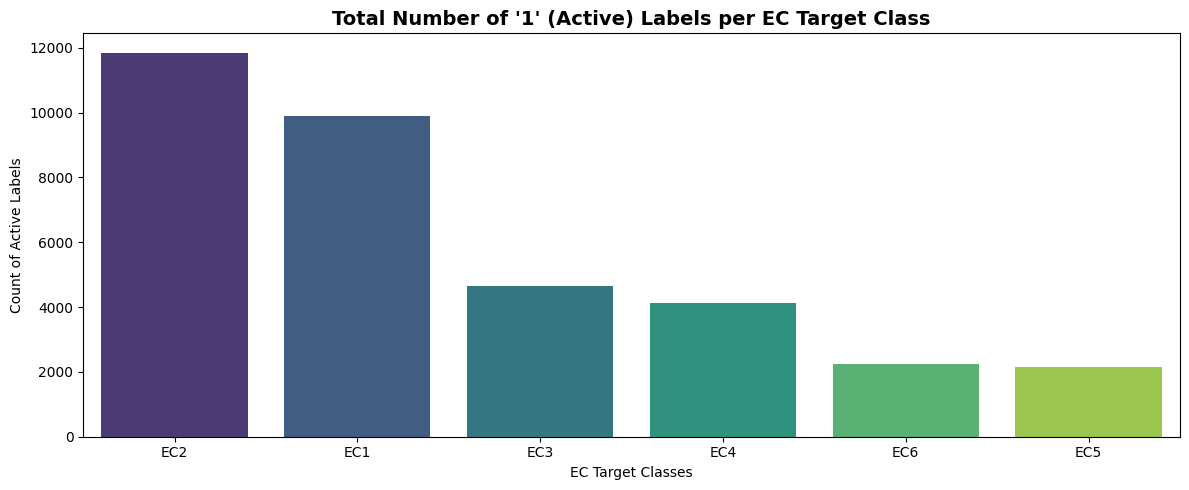


--- Target Class Imbalance Percentages (%) ---
EC1 -> Class 0: 33.23% | Class 1: 66.77%
EC2 -> Class 0: 20.10% | Class 1: 79.90%
EC3 -> Class 0: 68.62% | Class 1: 31.38%
EC4 -> Class 0: 72.09% | Class 1: 27.91%
EC5 -> Class 0: 85.52% | Class 1: 14.48%
EC6 -> Class 0: 84.84% | Class 1: 15.16%


In [16]:
# Targer Class Distribution (EC1 - EC6)
target_cols = ['EC1', 'EC2', 'EC3', 'EC4', 'EC5', 'EC6']

plt.figure(figsize=(12, 5))
target_counts = train_df[target_cols].sum().sort_values(ascending=False)
sns.barplot(x=target_counts.index, y=target_counts.values, palette="viridis")
plt.title("Total Number of '1' (Active) Labels per EC Target Class", fontsize=14, fontweight='bold')
plt.ylabel("Count of Active Labels")
plt.xlabel("EC Target Classes")
plt.tight_layout()
plt.show()

print("\n--- Target Class Imbalance Percentages (%) ---")
for col in target_cols:
    percentages = train_df[col].value_counts(normalize=True) * 100
    # Checking if both 0 and 1 exist to avoid KeyErrors
    pct_0 = percentages.get(0, 0.0)
    pct_1 = percentages.get(1, 0.0)
    print(f"{col} -> Class 0: {pct_0:.2f}% | Class 1: {pct_1:.2f}%")

## 4. Feature Engineering & Data Preprocessing

In [17]:
# Adding chemical interaction ratios directly to train_df
train_df['Chi1_valence_ratio'] = train_df['Chi1v'] / (train_df['Chi1'] + 1e-6)
train_df['Chi2_valence_ratio'] = train_df['Chi2v'] / (train_df['Chi2n'] + 1e-6)

# Adding the exact same chemical interaction ratios directly to test_df
test_df['Chi1_valence_ratio'] = test_df['Chi1v'] / (test_df['Chi1'] + 1e-6)
test_df['Chi2_valence_ratio'] = test_df['Chi2v'] / (test_df['Chi2n'] + 1e-6)

In [18]:
# PEOE Structural Aggregations
# Identifying all columns containing 'PEOE_VSA'
peoe_cols = [col for col in train_df.columns if 'PEOE_VSA' in col]

# Calculating total surface area and charge variance directly
train_df['PEOE_VSA_total'] = train_df[peoe_cols].sum(axis=1)
train_df['PEOE_VSA_variance'] = train_df[peoe_cols].var(axis=1)

test_df['PEOE_VSA_total'] = test_df[peoe_cols].sum(axis=1)
test_df['PEOE_VSA_variance'] = test_df[peoe_cols].var(axis=1)

In [19]:
target_cols = ['EC1', 'EC2', 'EC3', 'EC4', 'EC5', 'EC6']

In [20]:
feature_cols = list(train_df.drop(columns=['id'] + target_cols).columns)

In [21]:
x_raw = train_df[feature_cols].copy()
y_final = train_df[target_cols].values

In [22]:
x_test_raw = test_df[feature_cols].copy()

In [23]:
x_train_raw, x_val_raw, y_train, y_val = train_test_split(x_raw, y_final, test_size=0.2, random_state=42)

In [24]:
scaler = RobustScaler()

In [25]:
scaler.fit(x_train_raw)

RobustScaler()

In [26]:
x_train_final = pd.DataFrame(scaler.transform(x_train_raw), columns=feature_cols)
x_val_final = pd.DataFrame(scaler.transform(x_val_raw), columns=feature_cols)
x_test_final = pd.DataFrame(scaler.transform(x_test_raw), columns=feature_cols)

## 5. Model Training, Optimization & Deployment Strategy

In [27]:
lgb_base = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [28]:
lgb_model = MultiOutputClassifier(lgb_base)

In [29]:
lgb_model.fit(x_train_final, y_train)

[LightGBM] [Info] Number of positive: 7916, number of negative: 3954
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003979 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7311
[LightGBM] [Info] Number of data points in the train set: 11870, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 9455, number of negative: 2415
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7311
[LightGBM] [Info] Number of data points in the train set: 11870, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM

MultiOutputClassifier(estimator=LGBMClassifier(class_weight='balanced',
                                               learning_rate=0.05,
                                               n_estimators=150, n_jobs=-1,
                                               random_state=42))

In [30]:
lgb_val_preds = lgb_model.predict(x_val_final)

In [31]:
target_cols = ['EC1', 'EC2', 'EC3', 'EC4', 'EC5', 'EC6']
print(classification_report(y_val, lgb_val_preds, target_names=target_cols, zero_division=0))

              precision    recall  f1-score   support

         EC1       0.78      0.70      0.74      1992
         EC2       0.84      0.69      0.76      2400
         EC3       0.44      0.54      0.49       938
         EC4       0.44      0.63      0.52       823
         EC5       0.31      0.48      0.37       430
         EC6       0.21      0.34      0.26       467

   micro avg       0.59      0.63      0.61      7050
   macro avg       0.50      0.56      0.52      7050
weighted avg       0.65      0.63      0.63      7050
 samples avg       0.61      0.63      0.60      7050



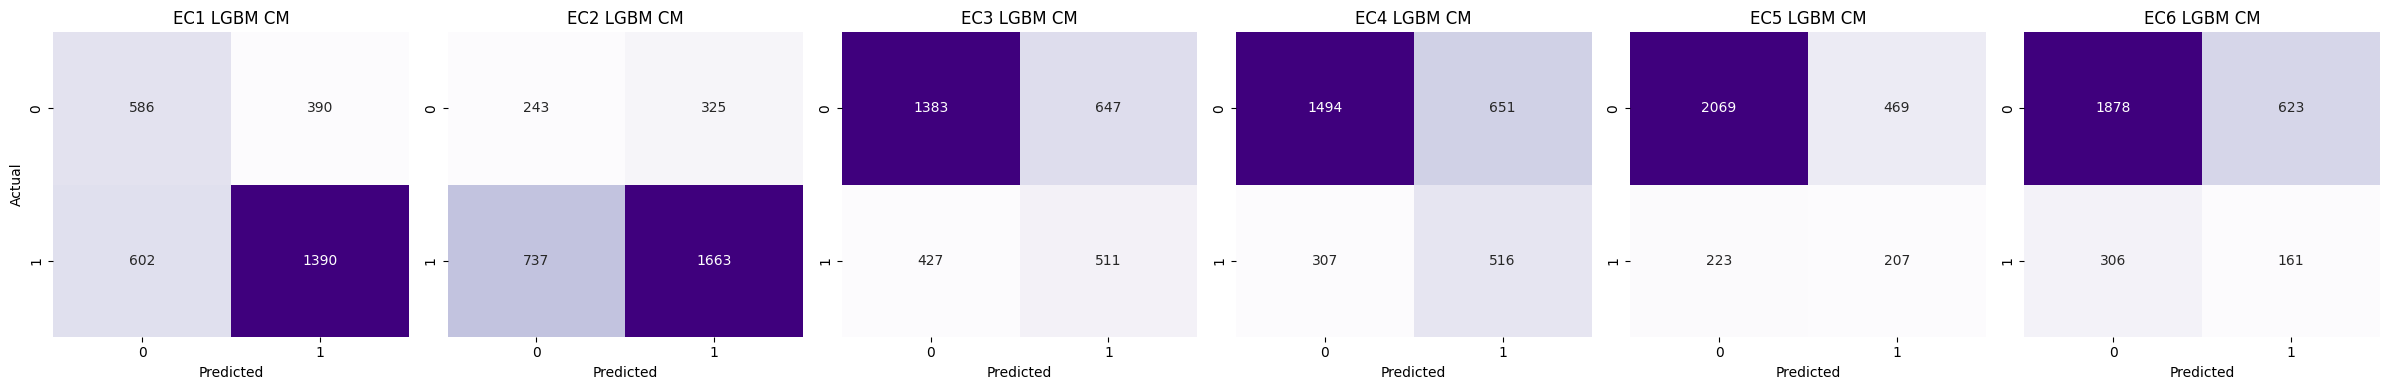

In [32]:
fig, axes = plt.subplots(1, 6, figsize=(24, 4))

cm_lgb0 = confusion_matrix(y_val[:, 0], lgb_val_preds[:, 0])
sns.heatmap(cm_lgb0, annot=True, fmt='d', cmap='Purples', ax=axes[0], cbar=False)
axes[0].set_title('EC1 LGBM CM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lgb1 = confusion_matrix(y_val[:, 1], lgb_val_preds[:, 1])
sns.heatmap(cm_lgb1, annot=True, fmt='d', cmap='Purples', ax=axes[1], cbar=False)
axes[1].set_title('EC2 LGBM CM')
axes[1].set_xlabel('Predicted')

cm_lgb2 = confusion_matrix(y_val[:, 2], lgb_val_preds[:, 2])
sns.heatmap(cm_lgb2, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False)
axes[2].set_title('EC3 LGBM CM')
axes[2].set_xlabel('Predicted')

cm_lgb3 = confusion_matrix(y_val[:, 3], lgb_val_preds[:, 3])
sns.heatmap(cm_lgb3, annot=True, fmt='d', cmap='Purples', ax=axes[3], cbar=False)
axes[3].set_title('EC4 LGBM CM')
axes[3].set_xlabel('Predicted')

cm_lgb4 = confusion_matrix(y_val[:, 4], lgb_val_preds[:, 4])
sns.heatmap(cm_lgb4, annot=True, fmt='d', cmap='Purples', ax=axes[4], cbar=False)
axes[4].set_title('EC5 LGBM CM')
axes[4].set_xlabel('Predicted')

cm_lgb5 = confusion_matrix(y_val[:, 5], lgb_val_preds[:, 5])
sns.heatmap(cm_lgb5, annot=True, fmt='d', cmap='Purples', ax=axes[5], cbar=False)
axes[5].set_title('EC6 LGBM CM')
axes[5].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [33]:
scaler = RobustScaler()

In [34]:
scaler.fit(x_raw)

RobustScaler()

In [35]:
x_train_final = pd.DataFrame(scaler.transform(x_raw), columns=feature_cols)

In [36]:
x_test_final = pd.DataFrame(scaler.transform(x_test_raw), columns=feature_cols)

In [38]:
final_lgb_base = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
final_lgb_model = MultiOutputClassifier(final_lgb_base)

In [39]:
final_lgb_model.fit(x_train_final, y_final)

[LightGBM] [Info] Number of positive: 9908, number of negative: 4930
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7410
[LightGBM] [Info] Number of data points in the train set: 14838, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 11855, number of negative: 2983
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7410
[LightGBM] [Info] Number of data points in the train set: 14838, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info]

MultiOutputClassifier(estimator=LGBMClassifier(class_weight='balanced',
                                               learning_rate=0.05,
                                               n_estimators=150, n_jobs=-1,
                                               random_state=42))

In [40]:
test_prob_list = final_lgb_model.predict_proba(x_test_final)

In [41]:
final_preds_prob_two_classes = np.column_stack([
    test_prob_list[0][:, 1],  
    test_prob_list[1][:, 1] 
])

In [42]:
target_cols = ['EC1', 'EC2']

submission_df = pd.DataFrame(final_preds_prob_two_classes, columns=target_cols)

submission_df.insert(0, 'id', test_df['id'].values)

submission_filename = 'submission_final_lgbm.csv'
submission_df.to_csv(submission_filename, index=False)

In [43]:
joblib_filename = 'enzyme_lgbm_multilabel_model.joblib'
joblib.dump(final_lgb_model, joblib_filename)

['enzyme_lgbm_multilabel_model.joblib']

In [44]:
scaler_filename = 'enzyme_robust_scaler.joblib'
joblib.dump(scaler, scaler_filename)

['enzyme_robust_scaler.joblib']

In [45]:
pickle_filename = 'enzyme_lgbm_multilabel_model.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(final_lgb_model, f)

In [46]:
scaler_pickle_filename = 'enzyme_robust_scaler.pkl'
with open(scaler_pickle_filename, 'wb') as f:
    pickle.dump(scaler, f)

In [47]:
config_data_updated = {
    "model_type": "LightGBM_MultiOutput",
    "task": "Multi-label Molecular Classification",
    "saved_with": "joblib",
    "model_file": "lgbm_multilabel_model.joblib",
    "scaler_file": "robust_scaler.joblib",
    "features_count": int(x_raw.shape[1]),
    "target_classes": ["EC1", "EC2"]
}

with open('enzyme_config.json', 'w') as f:
    json.dump(config_data_updated, f, indent=4)